<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/Main_quest/Quest01/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

라이브러리 및 데이터 불러와 결측치 확인하기

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

# Shape and preview
print('Train set shape:', train.shape)
print('Test set shape:', test.shape)
train.head()

Train set shape: (8693, 14)
Test set shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [10]:
train.isnull().sum()


,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [11]:
test.isnull().sum()

,0
PassengerId,0
HomePlanet,87
CryoSleep,93
Cabin,100
Destination,92
Age,91
VIP,93
RoomService,82
FoodCourt,106
ShoppingMall,98


<Axes: >

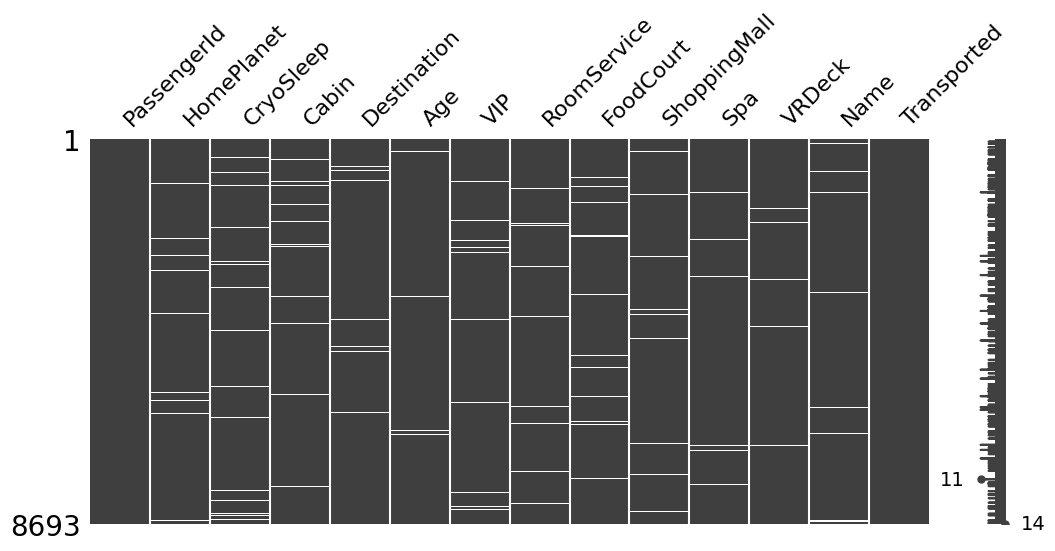

In [12]:
import missingno as msno
msno.matrix(train, figsize=(12, 5))

<Axes: >

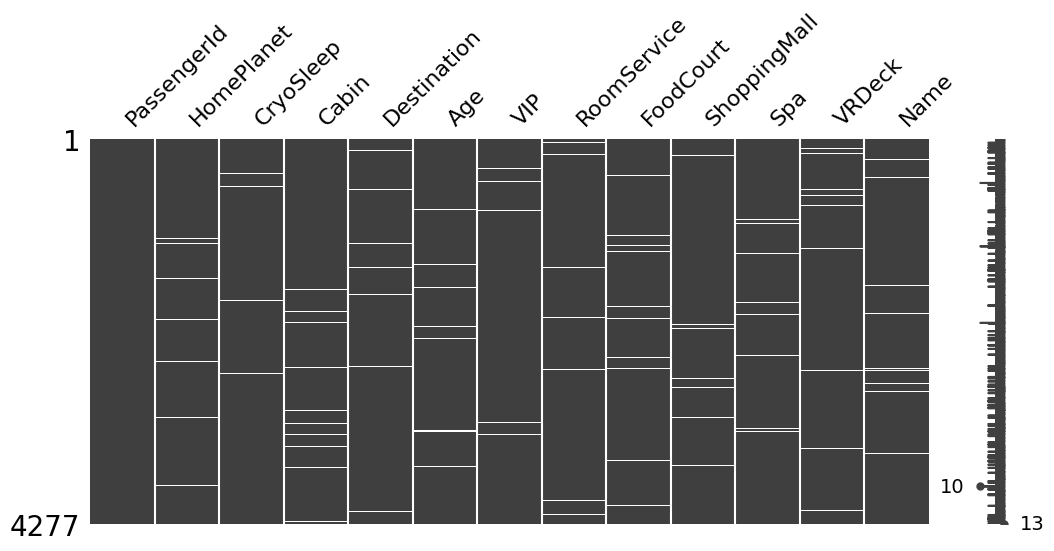

In [13]:
import missingno as msno
msno.matrix(test, figsize=(12, 5))

**EDA**

<Axes: ylabel='count'>

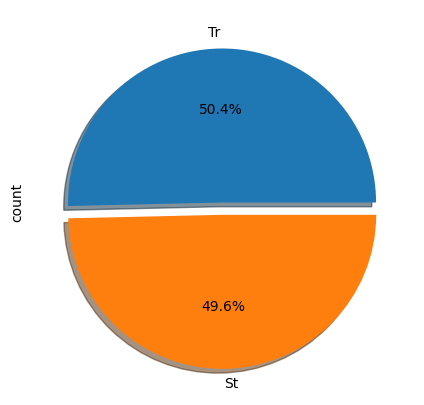

In [14]:
# 차원이동 확인

train["Transported"].value_counts()

plt.figure(figsize=(8, 5))
labels = ['Tr', 'St']
train['Transported'].value_counts().plot.pie(explode=[0, 0.08],
                                          shadow=True,
                                          autopct='%1.1f%%',
                                          labels=labels)

In [15]:
train['Age'].describe()

,Age
count,8514.000000
mean,28.827930
std,14.489021
min,0.000000
25%,19.000000
50%,27.000000
75%,38.000000
max,79.000000


In [16]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 84.7 MB/s eta 0:00:00


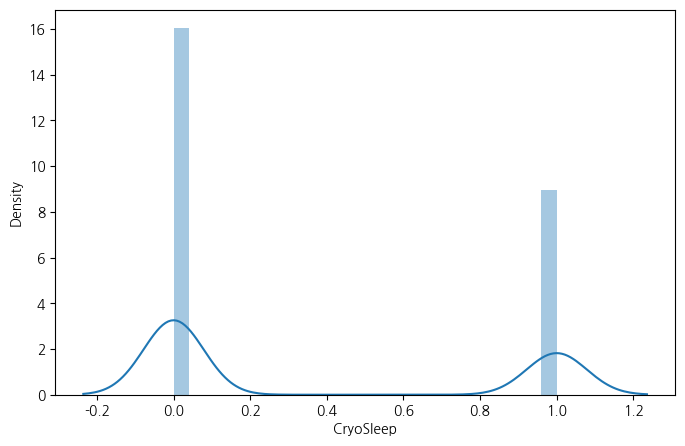

In [66]:
plt.figure(figsize=(8, 5))
sns.distplot(train['CryoSleep'], bins=25)
#plt.rc('font', family='Malgun Gothic')
import koreanize_matplotlib

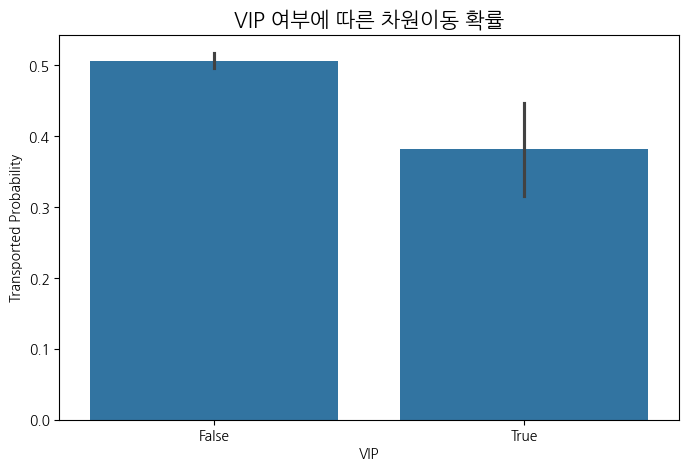

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# VIP 여부에 따른 Transported 비율 시각화
sns.barplot(x='VIP', y='Transported', data=train)

plt.title('VIP 여부에 따른 차원이동 확률', size=15)
plt.ylabel('Transported Probability')
plt.show()

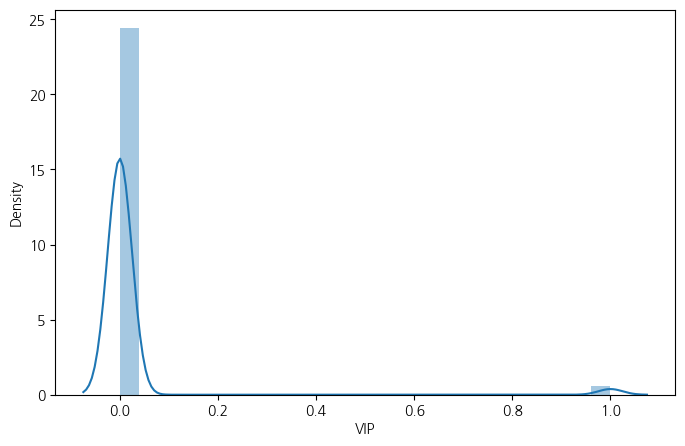

In [67]:
plt.figure(figsize=(8, 5))
sns.distplot(train['VIP'], bins=25)
#plt.rc('font', family='Malgun Gothic')
import koreanize_matplotlib

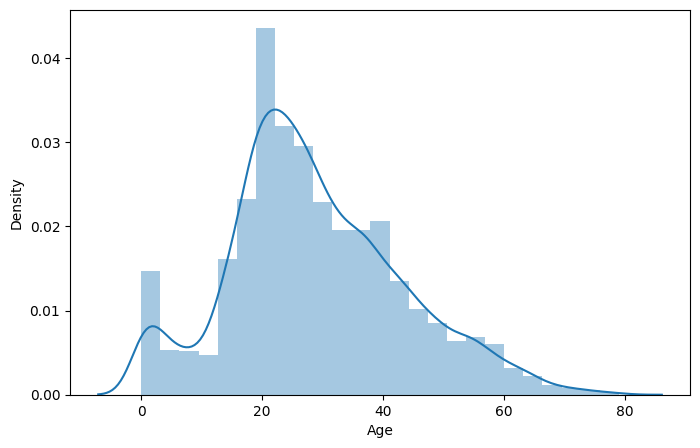

In [17]:
plt.figure(figsize=(8, 5))
sns.distplot(train['Age'], bins=25)
#plt.rc('font', family='Malgun Gothic')
import koreanize_matplotlib

<Axes: xlabel='Age', ylabel='Density'>

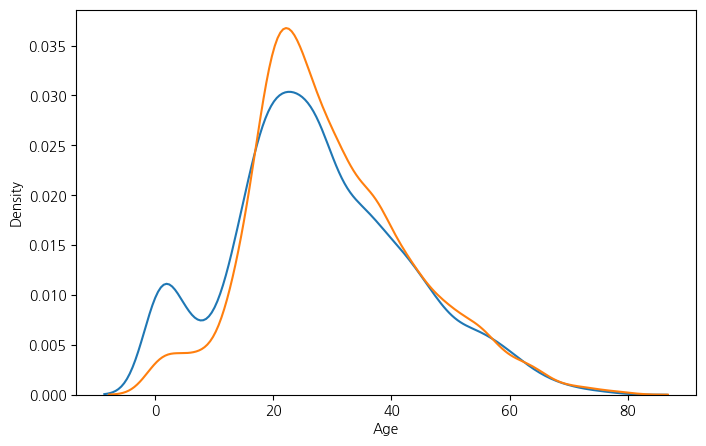

In [18]:
Tr = train[train['Transported'] == 1]
St = train[train['Transported'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(Tr['Age'], bins=25, hist=False)
sns.distplot(St['Age'], bins=25, hist=False)

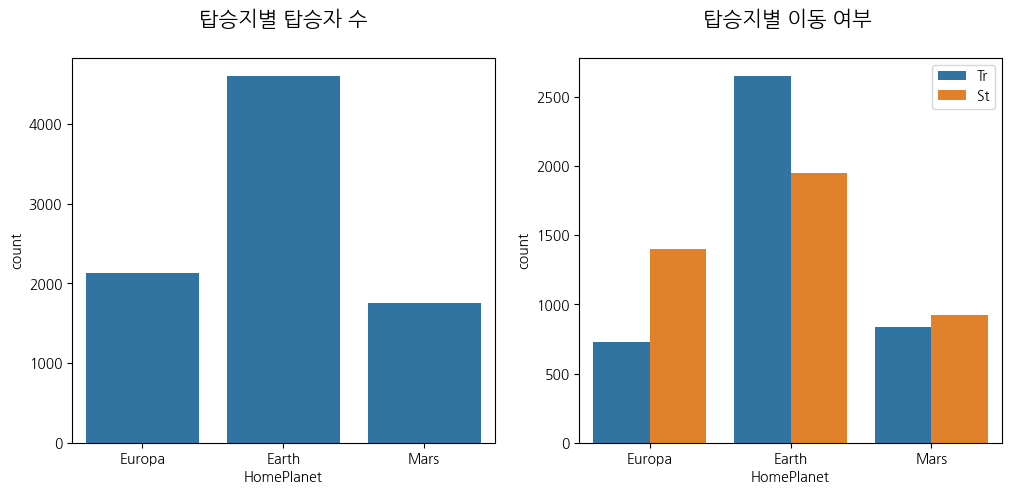

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title(" 탑승지별 탑승자 수 \n", size=15)
sns.countplot(x="HomePlanet", data=train, ax=axes[0])

axes[1].set_title("탑승지별 이동 여부 \n", size=15)
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Tr', 'St'])

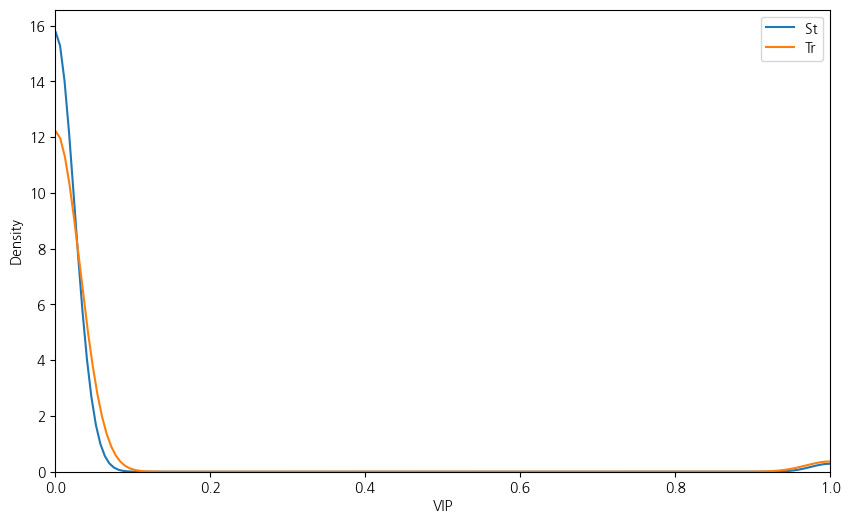

In [20]:
fig, ax = plt.subplots(figsize=(10,6))

# 분포 확인
sns.kdeplot(train[train['Transported']==1]['VIP'], ax=ax)
sns.kdeplot(train[train['Transported']==0]['VIP'], ax=ax)

# 축 범위
ax.set(xlim=(0, train['VIP'].max()))
ax.legend(['St', 'Tr'])

plt.show()

학습용 데이터 전처리 과정

In [70]:
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
train['GroupSize'] = train.groupby('Group')['Group'].transform('count')

In [75]:
train['Cabin'] = train['Cabin'].fillna('Unknown/Unknown/Unknown')
# 2. 슬래시(/)를 기준으로 열을 분리 (expand=True가 포인트!)
cabin_split = train['Cabin'].str.split('/', expand=True)

# 3. 각각의 컬럼에 할당
train['Deck'] = cabin_split[0]
train['CabinNum'] = cabin_split[1]
train['Side'] = cabin_split[2]

# 확인
print(train[['Deck', 'CabinNum', 'Side']].head())

  Deck CabinNum Side
0    B        0    P
1    F        0    S
2    A        0    S
3    A        0    S
4    F        1    S


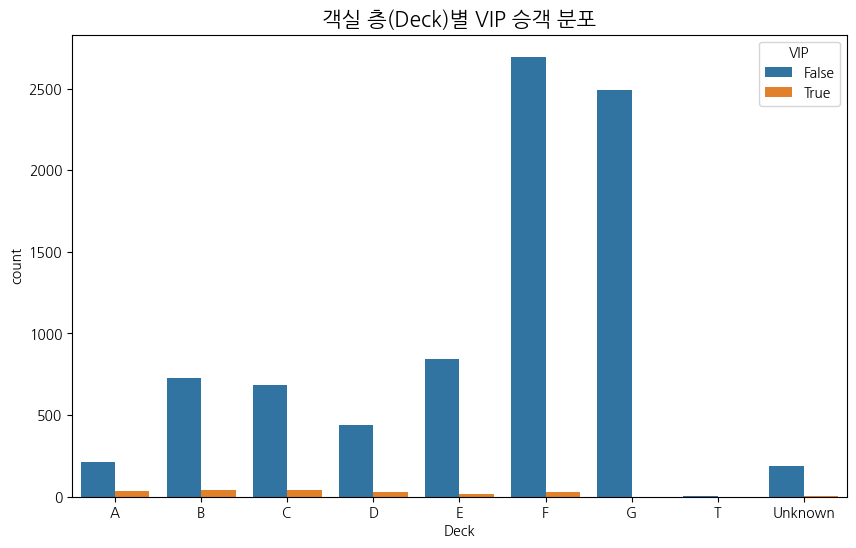

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Deck별로 VIP 여부를 나누어 시각화
sns.countplot(data=train, x='Deck', hue='VIP', order=sorted(train['Deck'].unique()))

plt.title('객실 층(Deck)별 VIP 승객 분포', size=15)
plt.show()

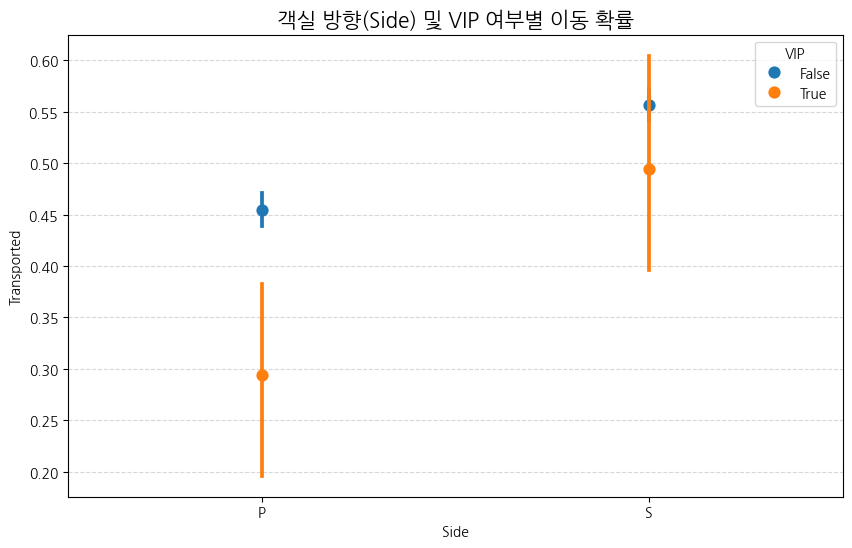

In [77]:
plt.figure(figsize=(10, 6))
# Side와 VIP 조합에 따른 Transported 확률
sns.pointplot(data=train, x='Side', y='Transported', hue='VIP', join=False)

plt.title('객실 방향(Side) 및 VIP 여부별 이동 확률', size=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

사이드 자리에 있는 승객이 차원이동의 확률이 크다

In [79]:
# CabinNum Median
train_cabin_nums = pd.to_numeric(train[train['CabinNum'] != 'Unknown']['CabinNum'], errors='coerce')
train.loc[train['CabinNum'] == 'Unknown', 'CabinNum'] = train_cabin_nums.median()
train['CabinNum'] = train['CabinNum'].astype(float)

In [78]:
# Spending
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    train[col] = train[col].fillna(0)
train['TotalSpend'] = train[spending_cols].sum(axis=1)


In [80]:
# Age
train['Age'] = train['Age'].fillna(train['Age'].median())
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 55, 100],
                             labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']).astype(str)


In [81]:
# CryoSleep logic
train.loc[(train['CryoSleep'].isnull()) & (train['TotalSpend'] > 0), 'CryoSleep'] = False
train['CryoSleep'] = train['CryoSleep'].fillna(False)

In [82]:
# Other Categoricals
for col in ['HomePlanet', 'Destination', 'VIP']:
    train[col] = train[col].fillna(train[col].mode()[0])

테스트 데이터 전처리과정

In [83]:
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0])
test['GroupSize'] = test.groupby('Group')['Group'].transform('count')

In [84]:
test['Cabin'] =   test['Cabin'].fillna('Unknown/Unknown/Unknown')
# 2. 슬래시(/)를 기준으로 열을 분리 (expand=True가 포인트!)
cabin_split = test['Cabin'].str.split('/', expand=True)

# 3. 각각의 컬럼에 할당
test['Deck'] = cabin_split[0]
test['CabinNum'] = cabin_split[1]
test['Side'] = cabin_split[2]

# 확인
print(test[['Deck', 'CabinNum', 'Side']].head())

  Deck CabinNum Side
0    G        3    S
1    F        4    S
2    C        0    S
3    C        1    S
4    F        5    S


In [85]:
# CabinNum Median
test_cabin_nums = pd.to_numeric(test[test['CabinNum'] != 'Unknown']['CabinNum'], errors='coerce')
test.loc[test['CabinNum'] == 'Unknown', 'CabinNum'] = test_cabin_nums.median()
test['CabinNum'] = test['CabinNum'].astype(float)

In [86]:
# Spending
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    test[col] = test[col].fillna(0)
test['TotalSpend'] = test[spending_cols].sum(axis=1)


In [87]:
# Age
test['Age'] = test['Age'].fillna(test['Age'].median())
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 12, 18, 35, 55, 100],
                             labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']).astype(str)


In [88]:
# CryoSleep logic
test.loc[(test['CryoSleep'].isnull()) & (test['TotalSpend'] > 0), 'CryoSleep'] = False
test['CryoSleep'] = test['CryoSleep'].fillna(False)

In [89]:
# Other Categoricals
for col in ['HomePlanet', 'Destination', 'VIP']:
    test[col] = train[col].fillna(test[col].mode()[0])

In [92]:

# --- 5. ENCODING & MODELING ---
from sklearn.preprocessing import LabelEncoder
features = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
            'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend',
            'Deck', 'Side', 'GroupSize', 'CabinNum', 'AgeGroup']

categorical_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']

# Concatenate for consistent encoding labels
combined = pd.concat([train[features], test[features]])
for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

X = combined.iloc[:len(train), :]
X_test = combined.iloc[len(train):, :]
y = train['Transported'].astype(int)
from sklearn.model_selection import train_test_split

# 학습 데이터를 다시 '학습용'과 '검증용'으로 8:2로 나눕니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 이후 model.fit(X_train, y_train)을 하고
# model.score(X_val, y_val)로 점수를 확인해 볼 수 있습니다.



In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 모델 정의 (하이퍼파라미터 설정)
# n_estimators: 나무의 개수, max_depth: 나무의 깊이 (너무 깊으면 과적합 주의)
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)

# 2. 학습용 데이터(X_train, y_train)로 모델 학습
rf.fit(X_train, y_train)

# 3. 검증용 데이터(X_val)로 예측해보기
y_pred = rf.predict(X_val)

# 4. 정확도 확인
accuracy = accuracy_score(y_val, y_pred)
print(f"Random Forest 검증 데이터 정확도: {accuracy:.4f}")

Random Forest 검증 데이터 정확도: 0.7913


In [114]:
# 1. 전체 데이터(X)로 모델 최종 학습
# (검증 데이터까지 포함하여 모든 데이터를 학습에 사용합니다)
rf_final = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf_final.fit(X, y)

# 2. 테스트 데이터(X_test)에 대해 예측 수행
# 결측치가 남아있을 경우를 대비해 한 번 더 체크
X_test = X_test.fillna(X_test.median())
final_preds = rf_final.predict(X_test)

# 3. 제출 양식에 맞춰 데이터프레임 생성
# Transported는 True/False 형태여야 하므로 다시 변환합니다.
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_preds.astype(bool)
})

# 4. CSV 파일로 저장
submission.to_csv('submission.csv', index=False)



In [109]:
# 1. 수치형 데이터(나이, 비용 등)는 중간값으로 채우기
X = X.fillna(X.median())
X_test = X_test.fillna(X_test.median())

# 2. 혹시 남아있을지 모를 범주형 데이터는 최빈값으로 채우기
X = X.fillna(X.mode().iloc[0])
X_test = X_test.fillna(X_test.mode().iloc[0])

# 3. 확인 (결과가 0이 나와야 합니다)
print(f"학습 데이터 결측치 개수: {X.isnull().sum().sum()}")

학습 데이터 결측치 개수: 0


In [128]:
from sklearn.ensemble import GradientBoostingClassifier

# 모델 정의
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 학습
gbc.fit(X_train, y_train)

# 예측 및 평가
gbc_pred = gbc.predict(X_val)
print(f"GradientBoosting 정확도: {accuracy_score(y_val, gbc_pred):.4f}")

GradientBoosting 정확도: 0.8022


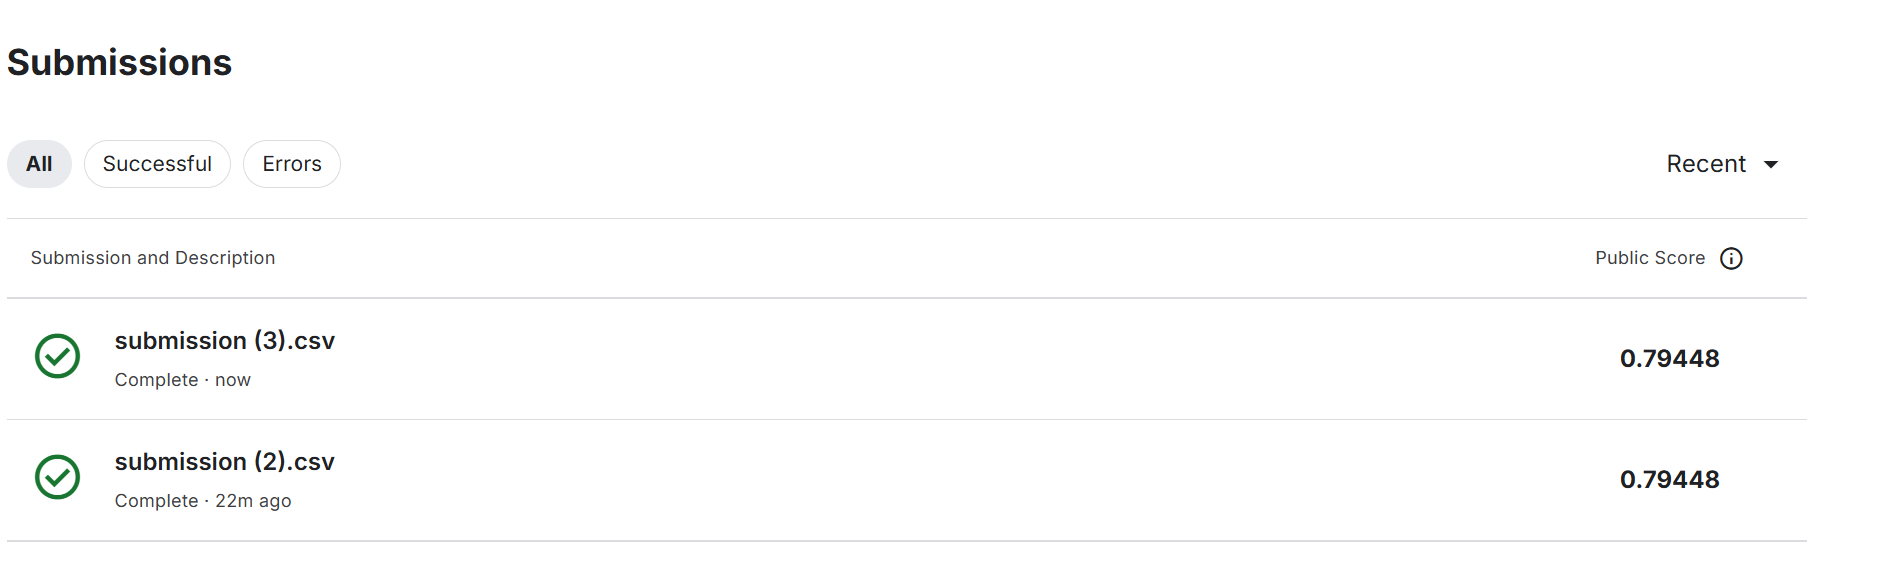